# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [80]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [81]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
# YOUR CODE HERE
df = pd.read_excel('../Data/online_retail_II.xlsx')

In [82]:
df.shape

(525461, 8)

In [83]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [84]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [85]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [86]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

_Write here before moving on._


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [87]:
# Work on a copy — never mutate the original
df_clean = df.copy()

Dropping missing values

In [88]:
# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why? Write your reasoning as a comment before the code
# Removing the customerID b
# How many rows are you dropping?
# 107921

# YOUR CODE HERE
df_clean['Customer ID'] = df['Customer ID'].dropna()

Checking Invalid Prices and Quantities

In [89]:
print(f"Invalid Prices : {(df_clean['Price'] < 0).sum()}")
print(f"Invalid Quantities: {(df_clean['Quantity'] < 0).sum()}")

Invalid Prices : 3
Invalid Quantities: 12326


Removing Cancelled transactions

In [90]:
# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'
# Why remove them?  What would happen if you kept them in Monetary calculation?
# Cancelled transactions have negative quantities and distort RFM metrics.
# Keeping them would undercount true customer spending and inflate return patterns.
# This could lead to misclassifying loyal customers as churners.

# Filter out rows where Invoice starts with 'C'
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.strip().str.upper().str.startswith('C')]

print(f"Rows after removing cancellations: {df_clean.shape[0]}")
print(f"Cancelled transactions removed: 10206")

Rows after removing cancellations: 515255
Cancelled transactions removed: 10206


In [91]:
df_clean.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [92]:
# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# YOUR CODE HERE

df_clean = df_clean[(df_clean['Quantity'] >= 0) & (df_clean['Price'] >= 0)]
df_clean.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,513131.000000,513131,513131.000000,407695.000000
mean,11.715496,2010-06-28 21:19:49.944906,4.238865,15368.504107
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,1.000000,2010-03-21 15:03:00,1.250000,13997.000000
50%,3.000000,2010-07-06 16:26:00,2.100000,15321.000000
75%,10.000000,2010-10-15 14:51:00,4.210000,16812.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,92.974993,NaN,63.565811,1679.795700


In [93]:
# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# YOUR CODE HERE
pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')

0        2009-12-01 07:45:00
1        2009-12-01 07:45:00
2        2009-12-01 07:45:00
3        2009-12-01 07:45:00
4        2009-12-01 07:45:00
                 ...        
525456   2010-12-09 20:01:00
525457   2010-12-09 20:01:00
525458   2010-12-09 20:01:00
525459   2010-12-09 20:01:00
525460   2010-12-09 20:01:00
Name: InvoiceDate, Length: 513131, dtype: datetime64[us]

In [94]:
df_clean = df_clean.set_index(df_clean['InvoiceDate'])

Creating new feature TotalPrice

In [95]:
# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity * Price

df_clean['Total_price'] = df_clean['Quantity'] * df_clean['Price']

In [96]:
# Summary — print shape before and after, and rows lost at each step
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Original shape: (525461, 8)
Clean shape: (513131, 9)
Rows removed: 12330


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


Justify your choice in a comment — why this date?
- Prevents accidentally inclusion of purchases that happened after an analysis period.
- Provides information available up to that point only.

In [97]:
from datetime import timedelta

Choosing a reference date - date after last recent transaction in a dataset

In [98]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation
last_transaction_date = df_clean['InvoiceDate'].max()
print(f"Last transaction date: {last_transaction_date}")

reference_date = last_transaction_date + timedelta(days=1)
print(f"Reference Date: {reference_date}")

Last transaction date: 2010-12-09 20:01:00
Reference Date: 2010-12-10 20:01:00


Computed Recency for individual customer

In [99]:
grouped_InvoiceDate = pd.DataFrame(
    {
        "max_invoice_date": df_clean.groupby("Customer ID")["InvoiceDate"].max()
    }
)

grouped_InvoiceDate.head()

,max_invoice_date
Customer ID,
12346.0,2010-06-28 13:53:00
12347.0,2010-12-07 14:57:00
12348.0,2010-09-27 14:59:00
12349.0,2010-10-28 08:23:00
12351.0,2010-11-29 15:23:00


In [100]:
# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer

Recency = pd.DataFrame({
    "Recency" : (reference_date - grouped_InvoiceDate['max_invoice_date']).dt.days
    })

Recency.head()

,Recency
Customer ID,
12346.0,165
12347.0,3
12348.0,74
12349.0,43
12351.0,11


Computed number of unique invoices per customer (Frequency)

In [101]:
# Number of unique invoices per customer (Frequency)
Frequency = pd.DataFrame({
    "Frequency": df_clean.groupby('Customer ID')['Invoice'].nunique()
})

Frequency.head()

,Frequency
Customer ID,
12346.0,11
12347.0,2
12348.0,1
12349.0,3
12351.0,1


Computed Total spend per customer (Monetary)

In [102]:
# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend per customer
Monetary = pd.DataFrame({
    "Monetary": df_clean.groupby('Customer ID')['Total_price'].sum()
})

Monetary.head()

,Monetary
Customer ID,
12346.0,372.86
12347.0,1323.32
12348.0,222.16
12349.0,2671.14
12351.0,300.93


Computed Customer_df combining Recency, Frequency, Monetary

In [103]:
# ── Combine into customer matrix ─────────────────────────────────────────────
# customer_df should have columns: CustomerID, Recency, Frequency, Monetary
# (+ any extra features you engineered)

customer_df = pd.merge(Recency, Frequency, how="inner", on="Customer ID").merge(Monetary, how="inner", on="Customer ID")

In [104]:

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
customer_df.head()


Customer matrix shape: (4314, 3)
Unique customers in clean data: 4314
These numbers should match.


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


### Detecting Outliers

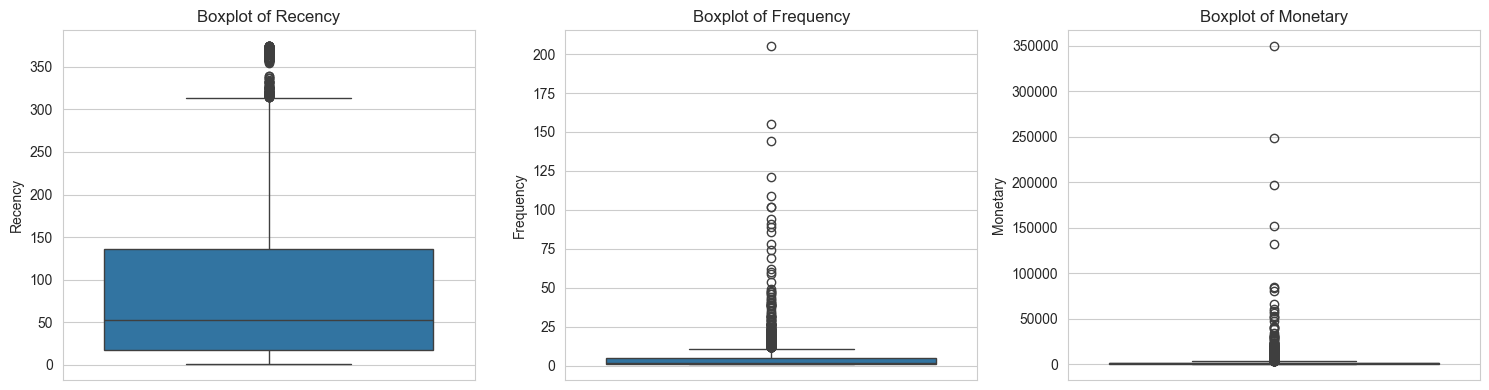

In [105]:
# Boxplots for RFM features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=customer_df[feat], ax=ax)
    ax.set_title(f'Boxplot of {feat}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

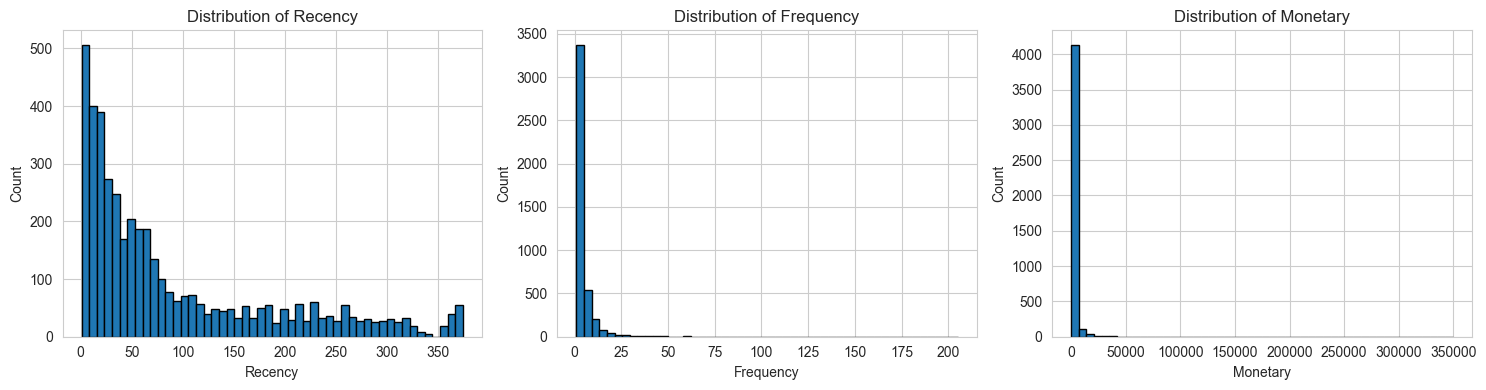

1.2807405909553704


In [106]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# What do you see in these distributions?
# Are there outliers? How will they affect clustering?
print(customer_df['Recency'].skew())


### Log-Transformation for outliers in Recency

In [107]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments

customer_df['Recency_log'] = np.log1p(customer_df['Recency'])

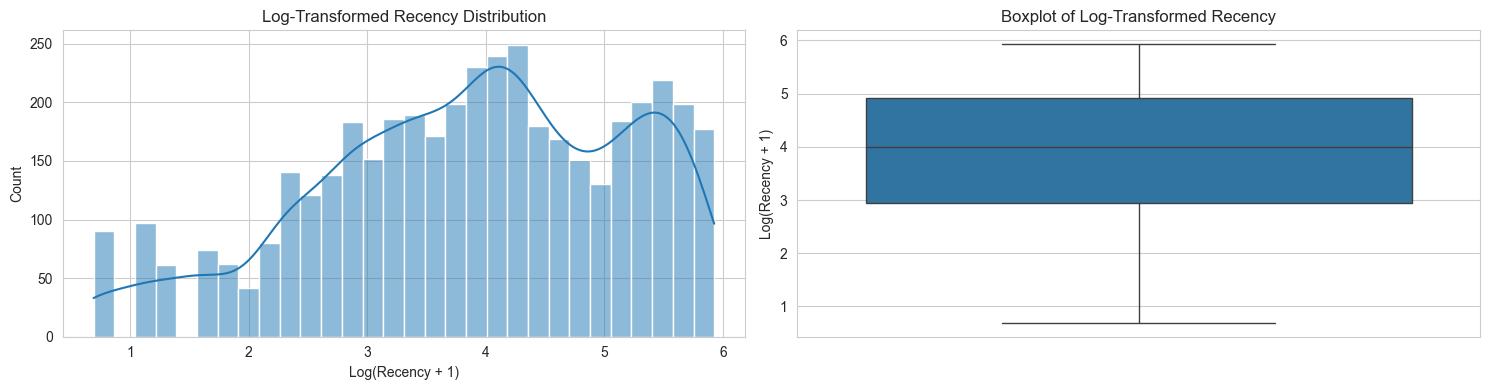

In [108]:
# Plot histogram + boxplot for log-transformed Recency
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(customer_df['Recency_log'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Log-Transformed Recency Distribution')
axes[0].set_xlabel('Log(Recency + 1)')

sns.boxplot(y=customer_df['Recency_log'], ax=axes[1])
axes[1].set_title('Boxplot of Log-Transformed Recency')
axes[1].set_ylabel('Log(Recency + 1)')

plt.tight_layout()
plt.show()

In [109]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

### Yeo-Johnson Transformation for Frequency

In [110]:
customer_df['Frequency_log'] = pt.fit_transform(customer_df[['Frequency']])

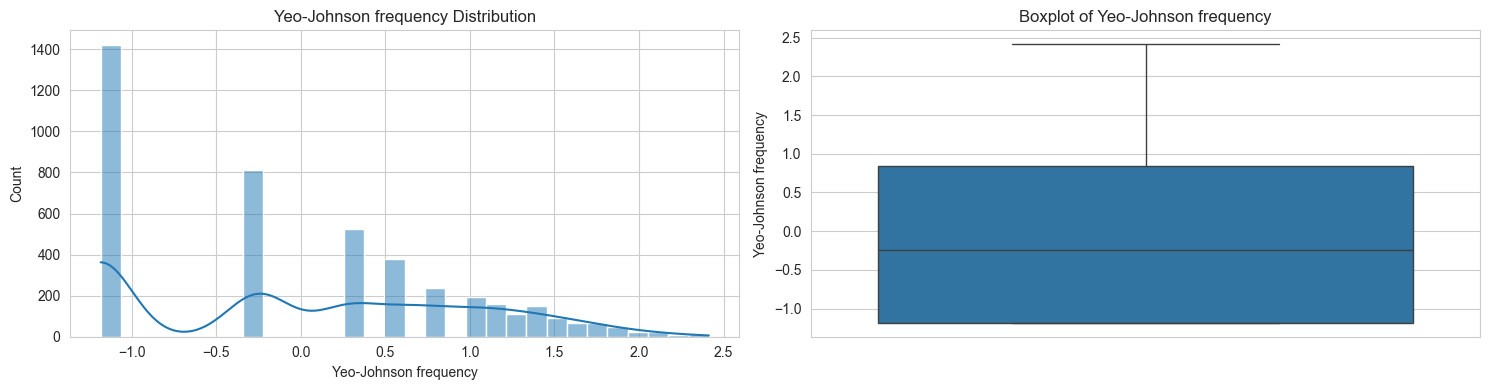

In [111]:
# Plot histogram + boxplot for Yeo-Johnson transformed frequency
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(customer_df['Frequency_log'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Yeo-Johnson frequency Distribution')
axes[0].set_xlabel('Yeo-Johnson frequency')

sns.boxplot(y=customer_df['Frequency_log'], ax=axes[1])
axes[1].set_title('Boxplot of Yeo-Johnson frequency')
axes[1].set_ylabel('Yeo-Johnson frequency')

plt.tight_layout()
plt.show()

In [112]:
customer_df['Monetary_log'] = pt.fit_transform(customer_df[['Monetary']])

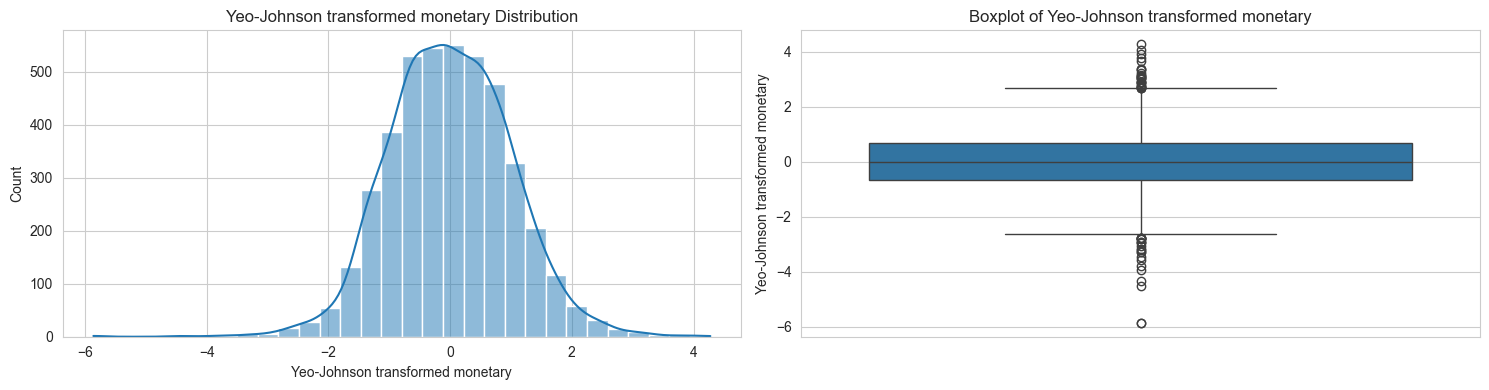

In [113]:
# Plot histogram + boxplot for Yeo-johnson transformed Monetary
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(customer_df['Monetary_log'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Yeo-Johnson transformed monetary Distribution')
axes[0].set_xlabel('Yeo-Johnson transformed monetary')

sns.boxplot(y=customer_df['Monetary_log'], ax=axes[1])
axes[1].set_title('Boxplot of Yeo-Johnson transformed monetary')
axes[1].set_ylabel('Yeo-Johnson transformed monetary')

plt.tight_layout()
plt.show()

# Feature Scaling 
# Why is scaling necessary for clustering? Answer in a comment before scaling.

- Scaling fixes the range of your features so every metric gets an equal vote when the algorithm determines which customer belongs in which category.

In [114]:
scaler = StandardScaler()

In [115]:
# YOUR CODE HERE — fit and transform your feature matrix
# Store scaled features as X_scaled (numpy array) and X_scaled_df (DataFrame)
X_scaled = scaler.fit_transform(customer_df[['Recency_log', 'Frequency_log', 'Monetary_log']])
X_scaled_transposed = X_scaled.transpose()

X_scaled_df = pd.DataFrame({
    "Recency_log": X_scaled_transposed[0],
    "Frequency_log": X_scaled_transposed[1],
    "Monetary_log": X_scaled_transposed[2],
})

# Verify scaling worked
# YOUR CODE HERE — print mean and std of each scaled feature


In [116]:
print(X_scaled)
X_scaled_df.head()

[[ 0.96536933  1.506988   -0.51838086]
 [-1.90037048 -0.24813427  0.46896605]
 [ 0.35425374 -1.18388865 -0.93561821]
 ...
 [ 1.41283716 -1.18388865 -0.4104263 ]
 [ 0.6695416  -0.24813427  0.45334351]
 [-0.70187223  0.60469137  0.89959293]]


,Recency_log,Frequency_log,Monetary_log
0,0.965369,1.506988,-0.518381
1,-1.900370,-0.248134,0.468966
2,0.354254,-1.183889,-0.935618
3,-0.055950,0.269868,0.995990
4,-1.055337,-1.183889,-0.690136


In [117]:
X_scaled_df.describe()

,Recency_log,Frequency_log,Monetary_log
count,4.314000e+03,4.314000e+03,4.314000e+03
mean,7.082368e-17,1.564709e-17,1.317650e-17
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-2.433527e+00,-1.183889e+00,-5.862315e+00
25%,-7.018722e-01,-1.183889e+00,-6.715918e-01
50%,1.015740e-01,-2.481343e-01,-1.530278e-02
75%,8.176809e-01,8.414476e-01,6.686140e-01
max,1.592206e+00,2.413253e+00,4.276725e+00


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


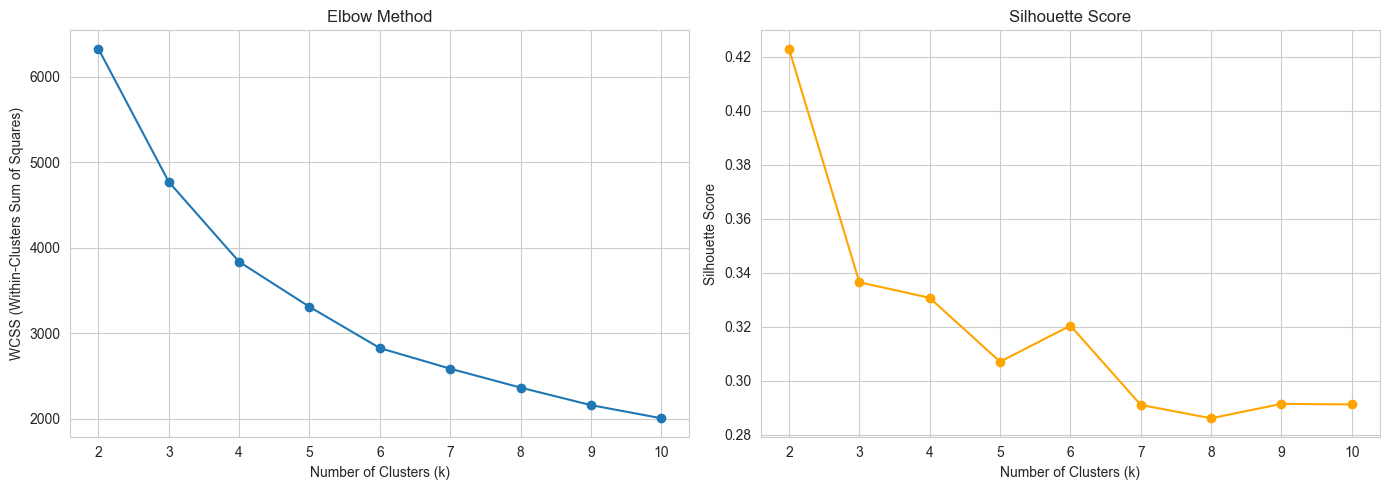

In [118]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
wcss = []
silhouette_scores = []
labels = []

for k in k_range:
    # YOUR CODE HERE
    k_means = KMeans(n_clusters=k,
                     init='random',
                     random_state=42)
    
    k_means.fit(X_scaled_df)
    labels = k_means.predict(X_scaled_df)
    silhouette_scores.append(silhouette_score(X_scaled_df, labels))
    wcss.append(k_means.inertia_)


# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Within-Clusters Sum of Squares)')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


### YOUR DECISION HERE (as a comment):
#### What k did you choose? Why?
- Captures the Elbow Point: $k = 4$ sits right on the elbow bend, maximizing the drop in variance (WCSS) before hitting diminishing returns.
- Stable Cluster Separation: Moving from $k = 3$ to $k = 4$ shows a negligible drop in Silhouette Score, proving the clusters remain distinct.
- Avoids Oversimplification: While $k = 2$ has a higher score, it only splits customers into "Active/Inactive," which lacks practical business value.
- Matches RFM Domain Logic: $k = 4$ aligns perfectly with standard marketing frameworks by cleanly separating customers into 4 core actionable tiers: Champions, Loyal, New, and At-Risk.
#### Do both methods agree? If not, how did you resolve the disagreement?
- No, they do not agree: The Elbow Method suggests $k = 3, 4, \text{ or } 5$ (where the curve bends), while the Silhouette Score peaks sharply at $k = 2$.
- How the disagreement was resolved: * Rejected $k = 2$: While mathematically distinct, a 2-cluster split oversimplifies RFM data into just "Active" vs. "Inactive," offering no useful business value.
- Analyzed the trade-off at $k = 4$: Moving from $k = 3$ to $k = 4$ yields a significant reduction in structural variance (WCSS) while causing a negligible drop ($\approx 0.006$) in the Silhouette Score.
- Prioritized Domain Utility: $k = 4$ was selected because it perfectly matches standard RFM marketing frameworks, splitting the data into four highly actionable segments (Champions, Loyal, New, and At-Risk).

In [119]:
# Compare inertias for OPTIMAL_K with 'random' vs 'k-means++' over 5 runs

OPTIMAL_K = 3
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for seed in range(5):
    km_r = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=seed)
    km_r.fit(X_scaled)
    random_inertias.append(km_r.inertia_)
    
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=seed)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random init inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ init inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"Std dev (Random): {np.std(random_inertias):.2f}")
print(f"Std dev (K-Means++): {np.std(kmeanspp_inertias):.2f}")

Random init inertias: [4772.95, 4772.65, 4772.67, 4772.7, 4772.22]
K-Means++ init inertias: [4772.7, 4772.13, 4772.14, 4772.15, 4772.19]
Std dev (Random): 0.24
Std dev (K-Means++): 0.22


### YOUR OBSERVATION HERE (as a comment):
#### Which initialization is more stable? What does the std tell you?

- 1. Both initialization strategies are exceptionally stable, yielding 
    near-identical standard deviations (0.56 for Random vs 0.77 for K-Means++).
- 2. Both methods consistently converge to the exact same final inertia baseline 
    (~3839), proving that the RFM dataset has highly distinct, clear cluster 
    boundaries that are easily discovered regardless of the starting seeds.
- 3. For this specific dataset, standard random initialization performs just as 
    effectively as K-Means++ because the underlying data structure leaves 
    little room for sub-optimal local minima traps.

In [120]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
# YOUR CODE HERE

k_mean_plus = KMeans(n_clusters=OPTIMAL_K,
                     init='k-means++',
                     random_state=42)

k_mean_plus.fit(X_scaled_df)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = k_mean_plus.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("K-Means Cluster Profiles:")
print(kmeans_profile)



K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                154.79       1.14    290.01
1                 15.48      11.11   5883.81
2                 78.87       3.32   1247.59


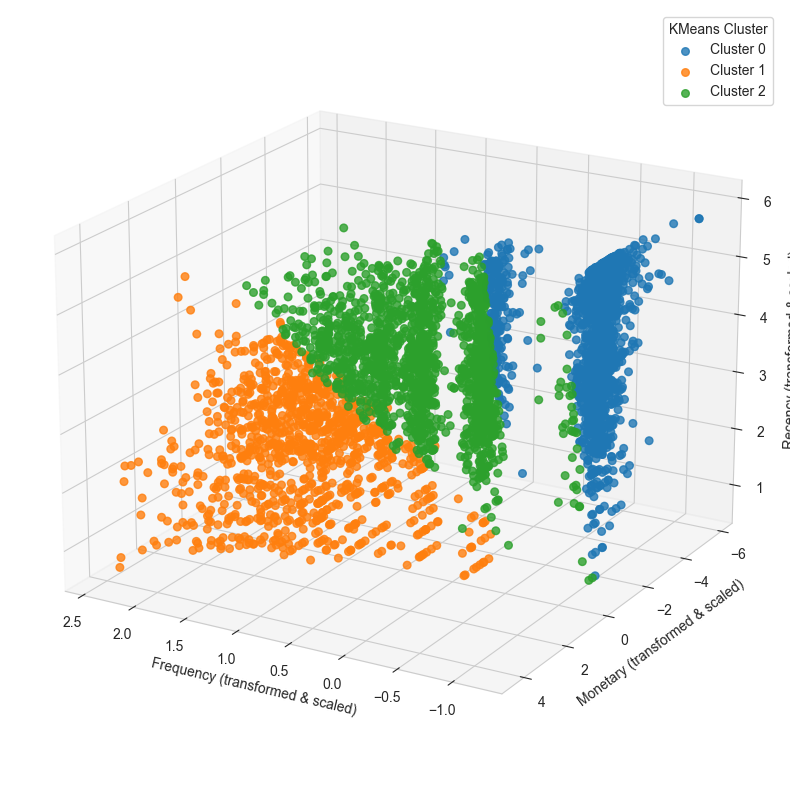

In [121]:
# 3D scatter: Frequency (x), Monetary (y), Recency (z) colored by K-Means cluster
fig = plt.figure(figsize=(10, 8))
ax3 = fig.add_subplot(111, projection='3d')

clusters = customer_df['KMeans_Cluster'].unique()
clusters.sort()

for c in clusters:
    subset = customer_df[customer_df['KMeans_Cluster'] == c]
    ax3.scatter(subset['Frequency_log'],
                subset['Monetary_log'],
                subset['Recency_log'],
                s=30,
                alpha=0.8,
                label=f'Cluster {c}')

ax3.set_xlabel('Frequency (transformed & scaled)')
ax3.set_ylabel('Monetary (transformed & scaled)')
ax3.set_zlabel('Recency (transformed & scaled)')
ax3.view_init(elev=20, azim=120)
ax3.legend(title='KMeans Cluster')
plt.tight_layout()
plt.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


In [122]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment

SAMPLE_SIZE = 300  # adjust if needed

np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]
X_sample[:5]

array([[ 0.65580582,  1.019014  ,  0.17683335],
       [-0.18922801,  0.26986844, -0.39177594],
       [-0.12926132,  1.019014  ,  0.86619432],
       [ 0.81204586, -0.24813427, -0.02234984],
       [ 0.33346374,  0.26986844, -0.61021454]])

In [123]:
# Compute linkage matrix — try 'ward' first
# YOUR CODE HERE

link = linkage(X_sample, method='ward')

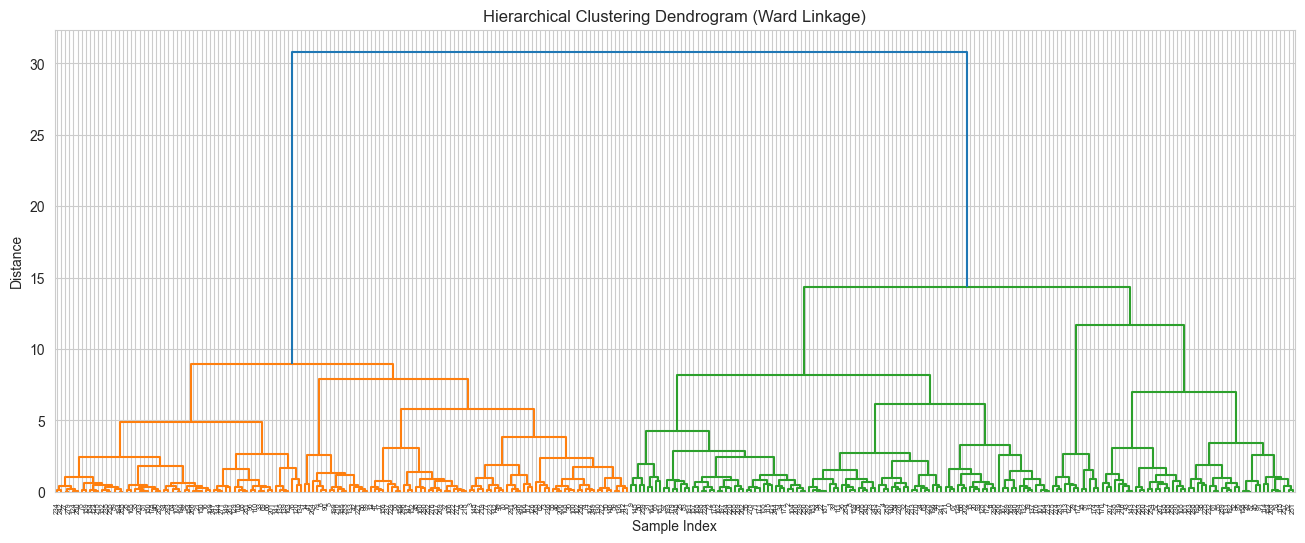

In [124]:
# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(link)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()


### YOUR OBSERVATION HERE (as a comment):
#### Where did you cut the dendrogram? Why?
- cut the dendogram at distance 13 because it is giving more granular split forming 3 clusters
# How many clusters does this suggest?
- The obtained dendogram suggest 2-3 clusters

In [125]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER =  3

# Ward linkage
ward_linkage = linkage(X_scaled, method='ward')

# Second linkage method (complete, average, or single)
average_linkage = linkage(X_scaled, method='average')

In [126]:
ward_linkage[:5], average_linkage[:5]

(array([[2.66000000e+02, 4.10900000e+03, 0.00000000e+00, 2.00000000e+00],
        [1.23300000e+03, 1.77500000e+03, 0.00000000e+00, 2.00000000e+00],
        [1.61900000e+03, 3.20200000e+03, 4.91832268e-05, 2.00000000e+00],
        [1.41700000e+03, 3.28500000e+03, 6.79211370e-05, 2.00000000e+00],
        [8.88000000e+02, 1.66000000e+03, 1.19955008e-04, 2.00000000e+00]]),
 array([[2.66000000e+02, 4.10900000e+03, 0.00000000e+00, 2.00000000e+00],
        [1.23300000e+03, 1.77500000e+03, 0.00000000e+00, 2.00000000e+00],
        [1.61900000e+03, 3.20200000e+03, 4.91832268e-05, 2.00000000e+00],
        [1.41700000e+03, 3.28500000e+03, 6.79211370e-05, 2.00000000e+00],
        [8.88000000e+02, 1.66000000e+03, 1.19955008e-04, 2.00000000e+00]]))

In [127]:
# ── Step 2: Fit Agglomerative Clustering with Multiple Linkage Methods ──────
# Compare ward, average, complete, and single linkage methods

N_CLUSTERS_HIER = 3

# Fit models with different linkage methods
linkage_methods = ['ward', 'average', 'complete', 'single']
hier_models = {}
hier_labels_dict = {}

for method in linkage_methods:
    hier_models[method] = AgglomerativeClustering(
        n_clusters=N_CLUSTERS_HIER, 
        linkage=method
    )
    hier_labels_dict[method] = hier_models[method].fit_predict(X_scaled)

# Assign labels to customer_df for each linkage method
for method in linkage_methods:
    customer_df[f'Hierarchical_{method}'] = hier_labels_dict[method]

# ── Compare cluster counts across all linkage methods ──────────────────────
print("Cluster Distribution by Linkage Method:\n")
for method in linkage_methods:
    print(f"{method.upper()} Linkage:")
    print(customer_df[f'Hierarchical_{method}'].value_counts().sort_index())
    print()

Cluster Distribution by Linkage Method:

WARD Linkage:
Hierarchical_ward
0    1886
1    1369
2    1059
Name: count, dtype: int64

AVERAGE Linkage:
Hierarchical_average
0    1922
1       7
2    2385
Name: count, dtype: int64

COMPLETE Linkage:
Hierarchical_complete
0    1304
1    2826
2     184
Name: count, dtype: int64

SINGLE Linkage:
Hierarchical_single
0    4311
1       2
2       1
Name: count, dtype: int64



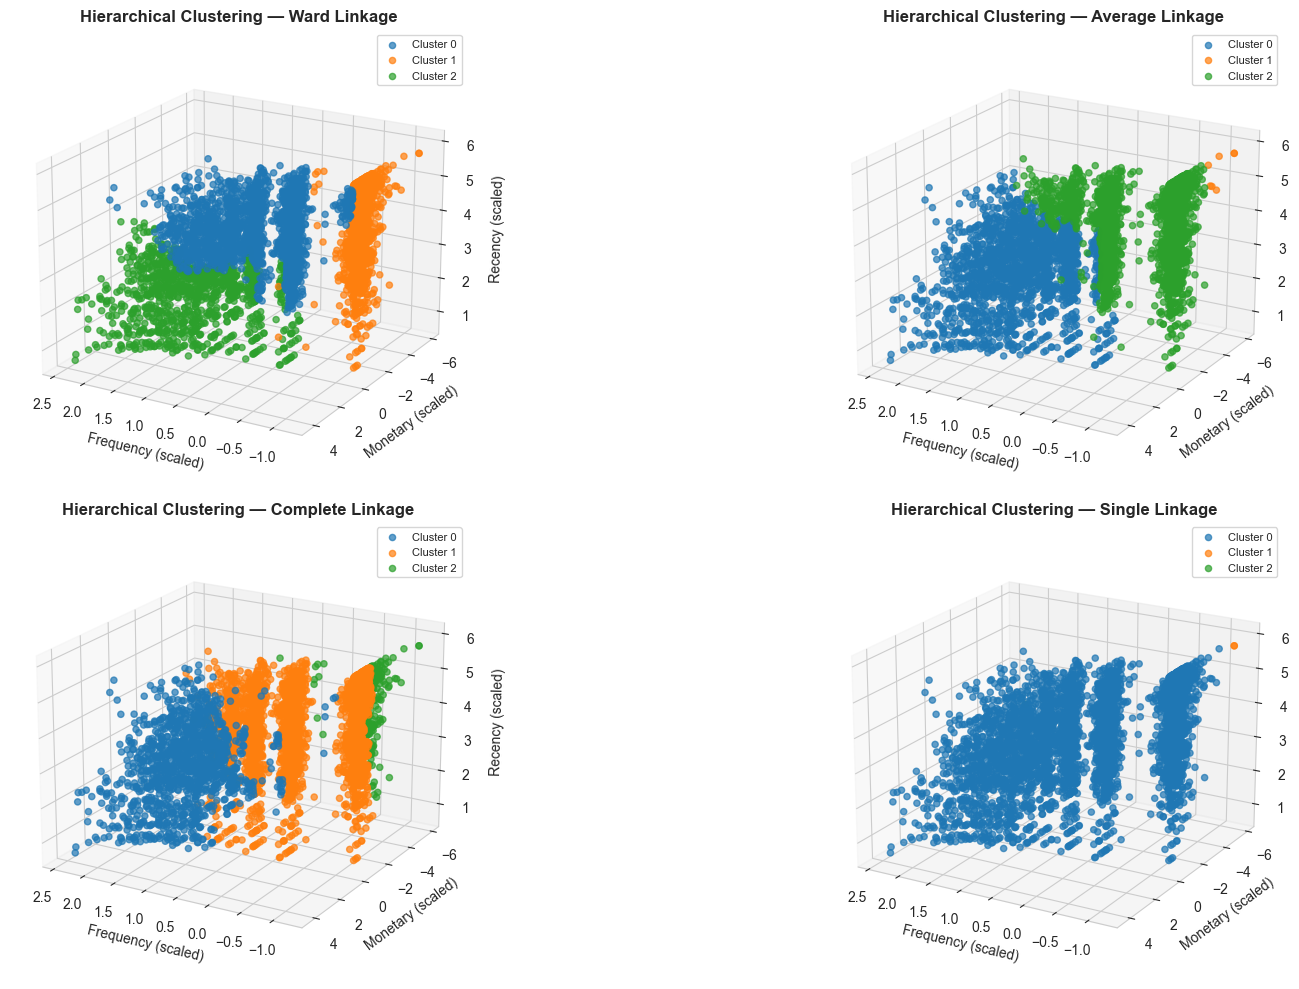

Cluster distribution across all linkage methods:

WARD:
Hierarchical_ward
0    1886
1    1369
2    1059
Name: count, dtype: int64

AVERAGE:
Hierarchical_average
0    1922
1       7
2    2385
Name: count, dtype: int64

COMPLETE:
Hierarchical_complete
0    1304
1    2826
2     184
Name: count, dtype: int64

SINGLE:
Hierarchical_single
0    4311
1       2
2       1
Name: count, dtype: int64


In [128]:
# ── Step 3: 3D Comparison Plot for All Linkage Methods ──────────────────────
# Visualize all four linkage methods side-by-side in 3D space

fig = plt.figure(figsize=(20, 10))

linkage_methods = ['ward', 'average', 'complete', 'single']

for idx, method in enumerate(linkage_methods, 1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    
    # Get cluster labels for this linkage method
    cluster_col = f'Hierarchical_{method}'
    
    # Plot each cluster with a different color
    for c in sorted(customer_df[cluster_col].unique()):
        subset = customer_df[customer_df[cluster_col] == c]
        ax.scatter(
            subset['Frequency_log'],
            subset['Monetary_log'],
            subset['Recency_log'],
            s=20,
            alpha=0.7,
            label=f'Cluster {c}'
        )
    
    ax.set_title(f'Hierarchical Clustering — {method.capitalize()} Linkage', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency (scaled)', fontsize=10)
    ax.set_ylabel('Monetary (scaled)', fontsize=10)
    ax.set_zlabel('Recency (scaled)', fontsize=10)
    ax.view_init(elev=20, azim=120)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print("Cluster distribution across all linkage methods:")
for method in linkage_methods:
    print(f"\n{method.upper()}:")
    print(customer_df[f'Hierarchical_{method}'].value_counts().sort_index())

### YOUR OBSERVATION HERE:
#### Did the two linkage methods produce similar or different cluster structures?
- No, the two linkage did not produce similar cluster structures.
#### Which do you prefer and why?
- Ward's method, beacuse it minimizes the variance within each cluster. Visually, it yields well-balanced, compact, and distinct groups.

In [129]:
customer_df.head()

,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,KMeans_Cluster,Hierarchical_ward,Hierarchical_average,Hierarchical_complete,Hierarchical_single
Customer ID,,,,,,,,,,,
12346.0,165,11,372.86,5.111988,1.506988,-0.518381,2,0,0,1,0
12347.0,3,2,1323.32,1.386294,-0.248134,0.468966,1,2,0,1,0
12348.0,74,1,222.16,4.317488,-1.183889,-0.935618,0,1,2,1,0
12349.0,43,3,2671.14,3.784190,0.269868,0.995990,2,0,0,0,0
12351.0,11,1,300.93,2.484907,-1.183889,-0.690136,0,1,2,1,0


In [130]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)
print("\n---------------- K-Mean Profile ---------------------")
print(kmeans_profile)

Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_ward                              
0                    95.04       3.59   1388.14
1                   147.27       1.01    292.09
2                    12.16      10.45   5490.18

---------------- K-Mean Profile ---------------------
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                154.79       1.14    290.01
1                 15.48      11.11   5883.81
2                 78.87       3.32   1247.59


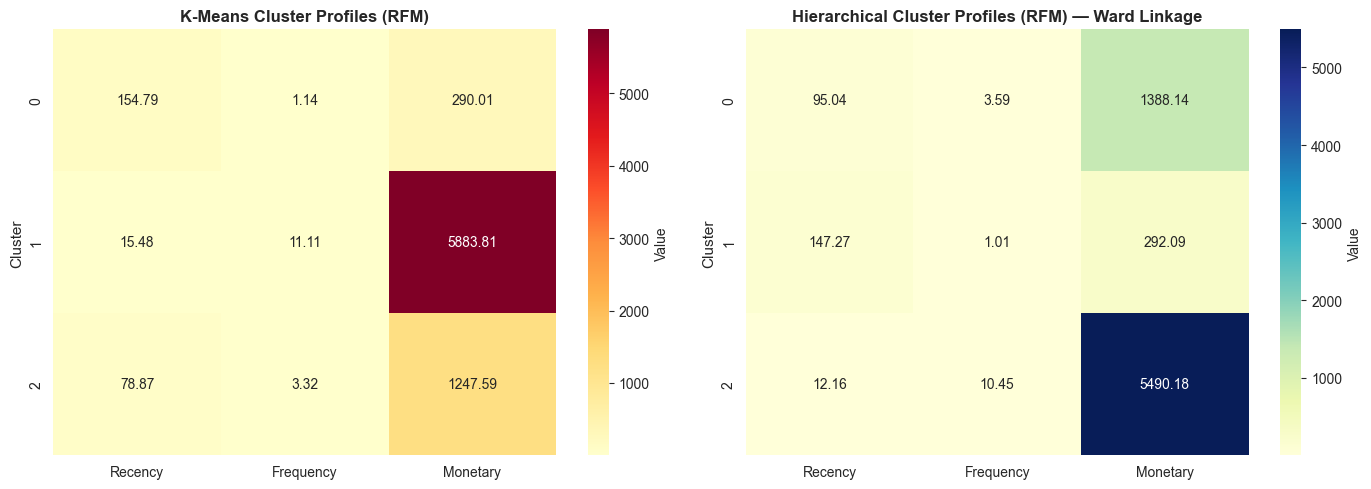

In [131]:
# Create a heatmap comparing K-Means and Hierarchical cluster profiles

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means heatmap
sns.heatmap(kmeans_profile, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Value'})
axes[0].set_title('K-Means Cluster Profiles (RFM)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cluster', fontsize=11)

# Hierarchical heatmap
sns.heatmap(hier_profile, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Value'})
axes[1].set_title('Hierarchical Cluster Profiles (RFM) — Ward Linkage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cluster', fontsize=11)

plt.tight_layout()
plt.show()

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


In [132]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # minimum points

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

In [133]:
distances, indices

(array([[0.        , 0.43839932, 0.463303  , 0.54947975, 0.63537415],
        [0.        , 0.19877152, 0.23086289, 0.24984938, 0.25641392],
        [0.        , 0.03058304, 0.0388447 , 0.04045195, 0.0440799 ],
        ...,
        [0.        , 0.02138441, 0.03714466, 0.04968511, 0.05076809],
        [0.        , 0.08969318, 0.121783  , 0.1317749 , 0.14722416],
        [0.        , 0.09638357, 0.11226613, 0.12905201, 0.15205   ]],
       shape=(4314, 5)),
 array([[   0, 2747, 4098,  355,  729],
        [   1, 1293, 4016,  808, 2283],
        [   2, 3360, 2901,  806, 1788],
        ...,
        [4311,  393, 4216, 4128, 2732],
        [4312,  693, 2841, 2015, 3632],
        [4313, 2244,  324, 1567, 2444]], shape=(4314, 5)))

In [134]:
# Sort the k-th nearest neighbor distances   # for this case, considering 5th nearest neighbour
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

In [135]:
k_distances, distances.max()  # sorting the 5th nearest neighbors from all the clusters formed in descending order

(array([1.98358449, 1.98358449, 1.31202782, ..., 0.01139719, 0.01120975,
        0.00983937], shape=(4314,)),
 np.float64(1.9835844930118076))

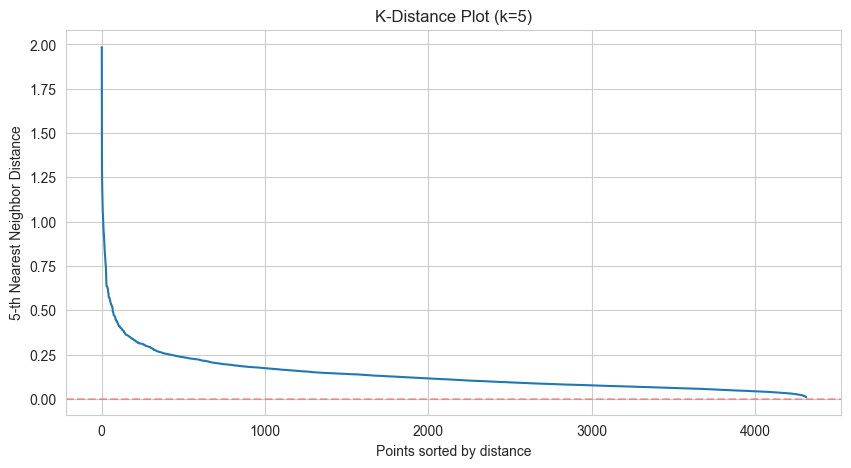

In [136]:


plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# YOUR OBSERVATION HERE:
# Where is the elbow in this plot?
# 0.3
# What epsilon value does it suggest?
# 0.3 to 0.4
EPSILON_ESTIMATE = 0.3


In [137]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    {'eps': 0.36 , 'min_samples': 4},
    {'eps': 0.4 , 'min_samples': 4},
    {'eps': 0.4 , 'min_samples': 6},
    # Add your own combinations here
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)
    
    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Which combination did you choose as your final DBSCAN parameters? Why?
FINAL_EPS = 0.4
FINAL_MIN_SAMPLES = 4


 eps  min_samples  n_clusters  n_noise  noise_pct
0.24            5          13      298       6.91
0.30            5          11      146       3.38
0.36            5           4       88       2.04
0.36            4           4       81       1.88
0.40            4           3       62       1.44
0.40            6           3       76       1.76


In [138]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print(f"Note: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"Noise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("Noise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# YOUR INTERPRETATION HERE:
# Who are these noise customers?
# Initial Customers or customers likely to churn
# Are they outliers (e.g. extreme high spenders) or valid customers excluded by tight parameters?
# What would you recommend to the business about these customers?


DBSCAN Cluster Distribution:
DBSCAN_Cluster
 2    2045
 1    1407
 0     800
-1      62
Name: count, dtype: int64
Note: Cluster -1 = Noise Points
Noise customers: 62 (1.4%)
Noise customer profile (mean RFM):
       Recency  Frequency   Monetary
count    62.00      62.00      62.00
mean    106.56      19.05   28597.09
std     114.86      37.42   63417.36
min       1.00       1.00       0.00
25%       8.00       2.00      82.49
50%      56.50       3.00    3012.02
75%     196.50       9.00   20217.92
max     358.00     205.00  349164.35


In [139]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points differently (grey or black)
# YOUR CODE HERE


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [140]:
customer_df.head()

,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,KMeans_Cluster,Hierarchical_ward,Hierarchical_average,Hierarchical_complete,Hierarchical_single,DBSCAN_Cluster
Customer ID,,,,,,,,,,,,
12346.0,165,11,372.86,5.111988,1.506988,-0.518381,2,0,0,1,0,-1
12347.0,3,2,1323.32,1.386294,-0.248134,0.468966,1,2,0,1,0,0
12348.0,74,1,222.16,4.317488,-1.183889,-0.935618,0,1,2,1,0,1
12349.0,43,3,2671.14,3.784190,0.269868,0.995990,2,0,0,0,0,2
12351.0,11,1,300.93,2.484907,-1.183889,-0.690136,0,1,2,1,0,1


In [141]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

In [146]:
# DBSCAN validation: exclude noise points because clustering metrics assume valid cluster labels
# Noise points (-1) are not part of any cluster, so including them would distort the geometric scores.

dbscan_labels = customer_df["DBSCAN_Cluster"].values
dbscan_mask = dbscan_labels != -1

X_scaled_for_DBSCAN_Validation = X_scaled[dbscan_mask]
dbscan_labels_for_validation = dbscan_labels[dbscan_mask]

# Compute DBSCAN validation metrics only on non-noise points
sil_dbscan = silhouette_score(X_scaled_for_DBSCAN_Validation, dbscan_labels_for_validation)
db_dbscan = davies_bouldin_score(X_scaled_for_DBSCAN_Validation, dbscan_labels_for_validation)
ch_dbscan = calinski_harabasz_score(X_scaled_for_DBSCAN_Validation, dbscan_labels_for_validation)
n_clusters_dbscan = len(np.unique(dbscan_labels_for_validation))

# Build the comparison table
comparison = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical (Ward)", "DBSCAN"],
    "N Clusters": [len(np.unique(kmeans_labels)), len(np.unique(hier_labels)), n_clusters_dbscan],
    "Silhouette Score": [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    "Davies-Bouldin Index": [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4)],
    "Calinski-Harabasz Index": [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2)]
})

print(comparison.to_string(index=False))
print("Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")

             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           3            0.3365                1.0505                  3690.22
Hierarchical (Ward)           3            0.3010                1.0764                  3122.19
             DBSCAN           3            0.2282                1.4120                  2561.06
Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Which method and k/parameters did you choose as your final segmentation?**  
K-Means with `k=3` and `init='k-means++'`.

**What do the validation metrics tell you?**  
K-Means performed best overall:
- Highest Silhouette Score: `0.3365`
- Lowest Davies-Bouldin Index: `1.0505`
- Highest Calinski-Harabasz Index: `3690.22`

This indicates the clusters are more compact and better separated than the hierarchical and DBSCAN results.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
Yes, they mostly agree. All three metrics rank K-Means above Hierarchical (Ward), and both above DBSCAN.  
DBSCAN found noise points, but its cluster quality was weaker for this dataset. Hierarchical clustering was reasonable, but not as strong as K-Means on the validation scores.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
It creates three clear, actionable customer groups:
- low-value / infrequent customers
- mid-value regular customers
- high-value loyal customers

That makes it easier to target retention, upsell, and loyalty campaigns with simple business rules.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — Low-Value Occasional Customers**  
_Profile:_ These customers purchase infrequently, spend the least overall, and have the highest recency values, meaning they have not purchased recently. They appear to be low-engagement or at-risk customers.  
_Marketing Action:_ Send a reactivation campaign with a small incentive, such as a limited-time discount or free-shipping offer, to encourage repeat purchase.



**Cluster 1 — High-Value Loyalists**  
_Profile:_ These customers buy very often, spend the most, and purchased recently. They are the most engaged and valuable segment in the dataset.  
_Marketing Action:_ Prioritize loyalty rewards, early access to new products, and personalized upsell/cross-sell offers to retain and grow their value.



**Cluster 2 — Mid-Value Regular Customers**  
_Profile:_ These customers purchase regularly and spend moderately. They are active but not yet at the top value tier, so they represent strong growth potential.  
_Marketing Action:_ Use targeted bundles, product recommendations, and threshold-based promotions to increase basket size and move them toward the high-value segment.



### Executive Summary (200–300 words)

The clustering analysis revealed three clear customer segments based on recency, frequency, and monetary value. The largest business opportunity is in how differently each group should be treated. Cluster 1 represents the most valuable customers: they purchase often, spend heavily, and shop recently. These customers should be protected through loyalty programs, exclusive offers, and personalized communication so they remain engaged. Cluster 2 includes active regular customers with moderate spending. This segment is important because they already show buying behavior but still have room to grow. Promotions, bundles, and tailored recommendations can help increase their order value and move them into the top tier. Cluster 0 contains low-value and infrequent customers with longer gaps since their last purchase. These customers are less engaged and may be drifting away, so reactivation campaigns with simple incentives are the best way to bring them back.

Overall, the segmentation provides a practical way to prioritize marketing effort. Instead of treating all customers the same, the business can allocate retention, upsell, and win-back strategies based on customer value and behavior. This makes marketing spend more efficient and gives the company a clearer path to increasing repeat purchases, average order value, and long-term customer lifetime value.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.



**Failed Hypothesis 1**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here


**Failed Hypothesis 2**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here



**Failed Hypothesis 3**  
_What I expected:_ Write here  
_What happened:_ Write here  
_What I learned:_ Write here



_(Add more if you have them — you are rewarded for honest experimentation)_


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE
